## Estimación del spatial lag y de indice de Moran
Se usará matriz de continuidad tipo Queen dada la extensión de las áreas y el régimen de lluvia, sin embargo se analizan también por distancia

In [1]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import esda

from libpysal import weights
from libpysal.weights import lag_spatial
from esda.moran import Moran, Moran_Local

cuencas=gpd.read_file(r"carto\cuencas_gauss.gpkg").set_index('HYBAS_ID')
cuencas=cuencas.to_crs(epsg=9377)
cuencas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 72 entries, 6080113930 to 6080094200
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   SUB_AREA        72 non-null     float64 
 1   cod_ah          72 non-null     float64 
 2   nom_ah          72 non-null     str     
 3   cod_zh          72 non-null     float64 
 4   nom_zh          72 non-null     str     
 5   cod_szh         72 non-null     float64 
 6   nom_szh         72 non-null     str     
 7   PMA_cuenca      72 non-null     float64 
 8   altura_mean     72 non-null     float64 
 9   area[km2]       72 non-null     float64 
 10  Beta_media      72 non-null     float64 
 11  Beta_std        72 non-null     float64 
 12  P24_media       72 non-null     float64 
 13  P24_std         72 non-null     float64 
 14  index_extremal  72 non-null     float64 
 15  FRA             72 non-null     float64 
 16  FRA_pred        72 non-null     float64 
 17

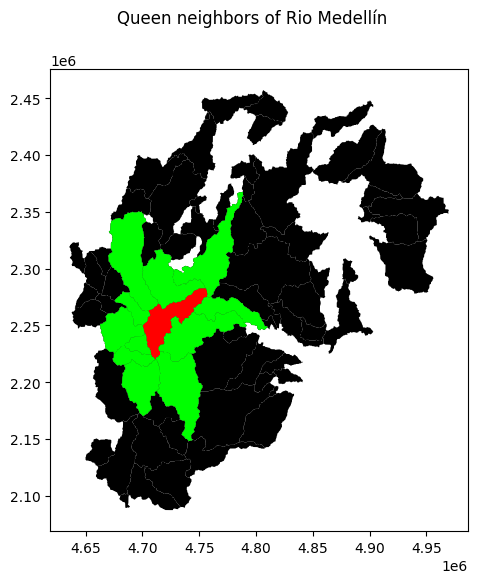

Número de islas: 0


In [2]:
# #=========================
# Matrices por contiguidad
# #=========================


w_queen = weights.Queen.from_dataframe(cuencas, use_index=True)
# Estandarizar por filas
w_queen.transform = "R"

#Verificar la vecindad con la cuenca del Río Medellín
import matplotlib.pyplot as plt

# Setup figure
f, ax = plt.subplots(1, figsize=(6, 6))

# Plot base layer of polygons
cuencas.plot(ax=ax, facecolor='k', linewidth=0.1)

# Select focal polygon
focus = cuencas.loc[[6080097500], ['geometry']]

# Plot focal polygon
focus.plot(facecolor='red', alpha=1, linewidth=0, ax=ax)

# Convert neighbors to list if necessary
neighbors_list = list(w_queen[6080097500])

# Plot neighbors
neis = cuencas.loc[neighbors_list, :]
neis.plot(ax=ax, facecolor='lime', linewidth=0)

# Add title
f.suptitle("Queen neighbors of Rio Medellín")

plt.show()

print('Número de islas:',len(w_queen.islands))

In [4]:
# ============================================================
# MATRICES POR DISTANCIA
# ============================================================

centroides = cuencas.geometry.centroid

coords = np.column_stack([
    centroides.x,
    centroides.y
])

# K vecinos más cercanos
w_knn5 = weights.KNN.from_array(
    coords,
    k=5
)

w_knn5.transform = "R"

# Matriz por distancia umbral
km = 20

w_dist20km = weights.DistanceBand.from_array(
    coords,
    threshold=km * 1000,
    binary=True,
    silence_warnings=True
)

w_dist20km.transform = "R"

print("KNN-5")
print("Número de islas:", len(w_knn5.islands))
print("Promedio de vecinos:", np.mean(list(w_knn5.cardinalities.values())))

print("\nDistancia 20 km")
print("Número de islas:", len(w_dist20km.islands))
print("Promedio de vecinos:", np.mean(list(w_dist20km.cardinalities.values())))

KNN-5
Número de islas: 0
Promedio de vecinos: 5.0

Distancia 20 km
Número de islas: 45
Promedio de vecinos: 0.4444444444444444


In [5]:
# ============================================================
# COMPARACIÓN DE MORAN CON DIFERENTES MATRICES
# ============================================================

def calcular_moran(variable, w, nombre_matriz):
    mi = Moran(
        cuencas[variable].values,
        w,
        permutations=999
    )
    
    return {
        "Variable": variable,
        "Matriz": nombre_matriz,
        "Moran_I": mi.I,
        "p_sim": mi.p_sim,
        "Esperado_I": mi.EI,
        "z_sim": mi.z_sim,
        "Islas": len(w.islands),
        "Promedio_vecinos": np.mean(list(w.cardinalities.values()))
    }


variables_moran = [
    "FRA",
    "residuo",
    "Beta_media"
]

matrices = {
    "Queen": w_queen,
    "KNN-5": w_knn5,
    "Distancia 20 km": w_dist20km
}

resultados = []

for variable in variables_moran:
    for nombre_matriz, w_temp in matrices.items():
        resultados.append(
            calcular_moran(variable, w_temp, nombre_matriz)
        )

tabla_moran = pd.DataFrame(resultados)

tabla_moran

,Variable,Matriz,Moran_I,p_sim,Esperado_I,z_sim,Islas,Promedio_vecinos
0,FRA,Queen,0.064211,0.213,-0.014085,0.801694,0,3.972222
1,FRA,KNN-5,0.210614,0.004,-0.014085,3.199677,0,5.000000
2,FRA,Distancia 20 km,0.135665,0.299,-0.014085,0.540938,45,0.444444
3,residuo,Queen,0.064185,0.161,-0.014085,0.968683,0,3.972222
4,residuo,KNN-5,0.087724,0.068,-0.014085,1.617659,0,5.000000
5,residuo,Distancia 20 km,0.094002,0.324,-0.014085,0.424991,45,0.444444
6,Beta_media,Queen,0.491504,0.001,-0.014085,5.638545,0,3.972222
7,Beta_media,KNN-5,0.526485,0.001,-0.014085,7.944168,0,5.000000
8,Beta_media,Distancia 20 km,0.715201,0.002,-0.014085,2.949252,45,0.444444


### Spatial Lag para FRA

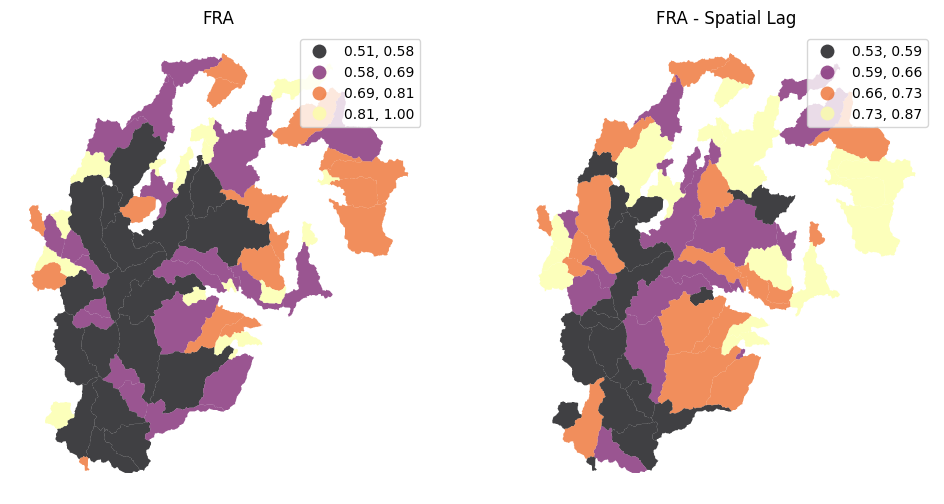

In [6]:
cuencas['w_FRA'] = weights.lag_spatial(w_queen, cuencas['FRA']) # Cambiar matriz de vecindad si se requiere 

f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs
cuencas.plot(column='FRA', cmap='inferno', scheme='quantiles',k=4, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax1)
ax1.set_axis_off()
ax1.set_title("FRA")
cuencas.plot(column='w_FRA', cmap='inferno', scheme='quantiles',k=4, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax2)
ax2.set_axis_off()
ax2.set_title("FRA - Spatial Lag")
plt.show()

### Gráfico de Moran
No se muestra una autocorrelación espacial estadísticamente significativa, sin embargo hay un Moran positivo

In [7]:
cuencas['FRA_std'] = ( cuencas['FRA'] - cuencas['FRA'].mean() )/ cuencas['FRA'].std()
cuencas['w_FRA_std'] = weights.lag_spatial(w_queen, cuencas['FRA_std'])
#cuencas['FRA_lag_std'] = ( cuencas['w_FRA_std'] - cuencas['w_FRA_std'].mean() )/ cuencas['w_FRA_std'].std()
mi=Moran(cuencas['FRA'],w_queen)
print(mi.I)
print(mi.p_sim)

0.06421068223219088
0.19


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.06', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.06)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

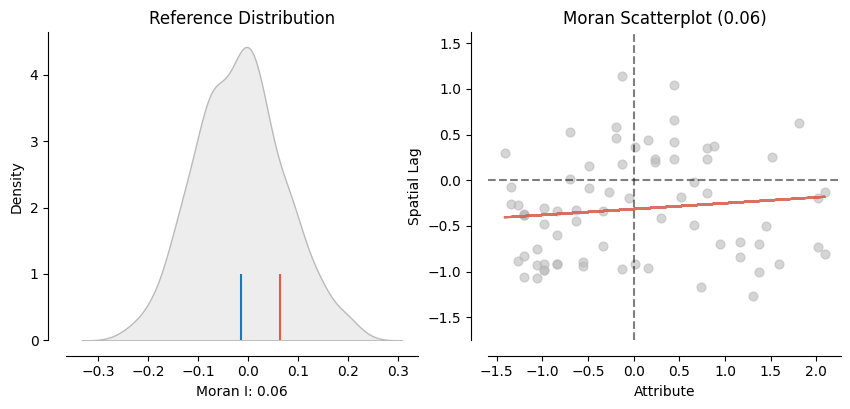

In [8]:
from splot.esda import plot_moran
plot_moran(mi)

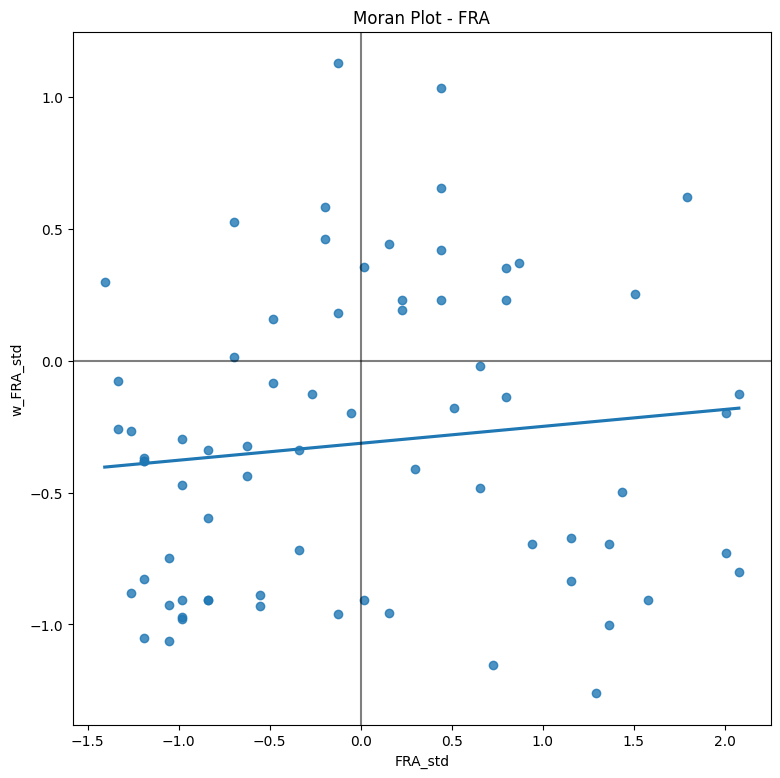

In [9]:
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot values
sns.regplot(x='FRA_std', y='w_FRA_std', data=cuencas, ci=None)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
ax.set_title('Moran Plot - FRA')
# Display
plt.show()

### Spatial Lag y Moran para el error en modelo Gaussiano
Tampoco se encuentra autocorrelación espacial dentro del error del modelo

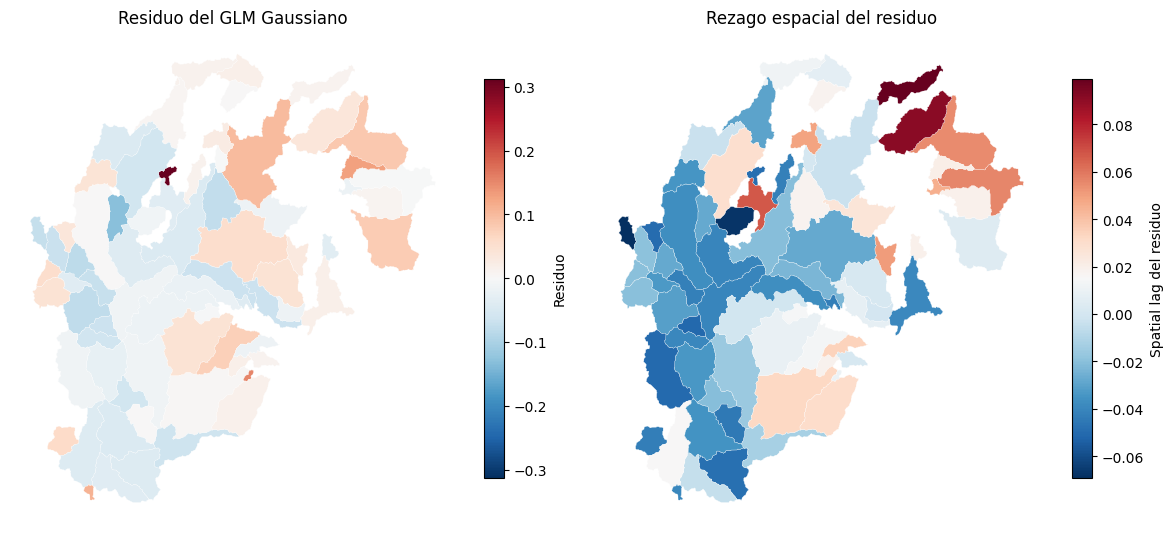

In [10]:
from matplotlib.colors import TwoSlopeNorm

cuencas['w_residuo'] = weights.lag_spatial(w_queen, cuencas['residuo']) # Cambiar matriz de vecindad si se requiere 

'''f, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1, ax2 = axs
cuencas.plot(column='residuo', cmap='viridis', scheme='quantiles',k=4, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax1)
ax1.set_axis_off()
ax1.set_title("residuo Gaussiano")
cuencas.plot(column='w_residuo', cmap='viridis', scheme='quantiles',k=4, edgecolor='white', linewidth=0., alpha=0.75, legend=True, ax=ax2)
ax2.set_axis_off()
ax2.set_title("residuo Gaussiano - Spatial Lag")
plt.show()'''
vmax = max(
    abs(cuencas["residuo"].min()),
    abs(cuencas["residuo"].max())
)

norm = TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax
)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

cuencas.plot(
    ax=ax[0],
    column="residuo",
    cmap="RdBu_r",
    norm=norm,
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    legend_kwds={
        "label": "Residuo",
        "shrink": 0.7
    }
)

cuencas.plot(
    ax=ax[1],
    column="w_residuo",
    cmap="RdBu_r",
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    legend_kwds={
        "label": "Spatial lag del residuo",
        "shrink": 0.7
    }
)

ax[0].set_title("Residuo del GLM Gaussiano")
ax[1].set_title("Rezago espacial del residuo")

for a in ax:
    a.set_axis_off()

plt.tight_layout()
plt.show()

0.06418510620705392
0.174


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.06', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.06)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

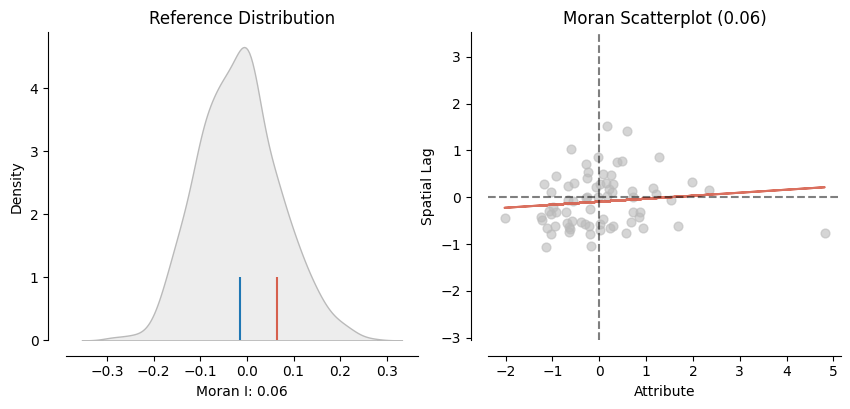

In [11]:
mi_error=Moran(cuencas['residuo'],w_queen)
print(mi_error.I)
print(mi_error.p_sim)
plot_moran(mi_error)

### Indicadores locales de asociación espacial (LISA)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

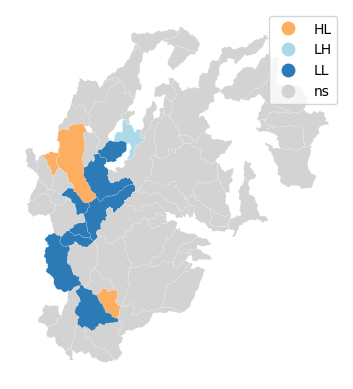

In [12]:
lisa = esda.Moran_Local(cuencas['residuo'], w_queen)
from splot.esda import lisa_cluster
lisa_cluster(lisa, cuencas)

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: title={'center': 'Moran Local Scatterplot'}, xlabel='Attribute', ylabel='Spatial Lag'>,
        <Axes: >, <Axes: >], dtype=object))

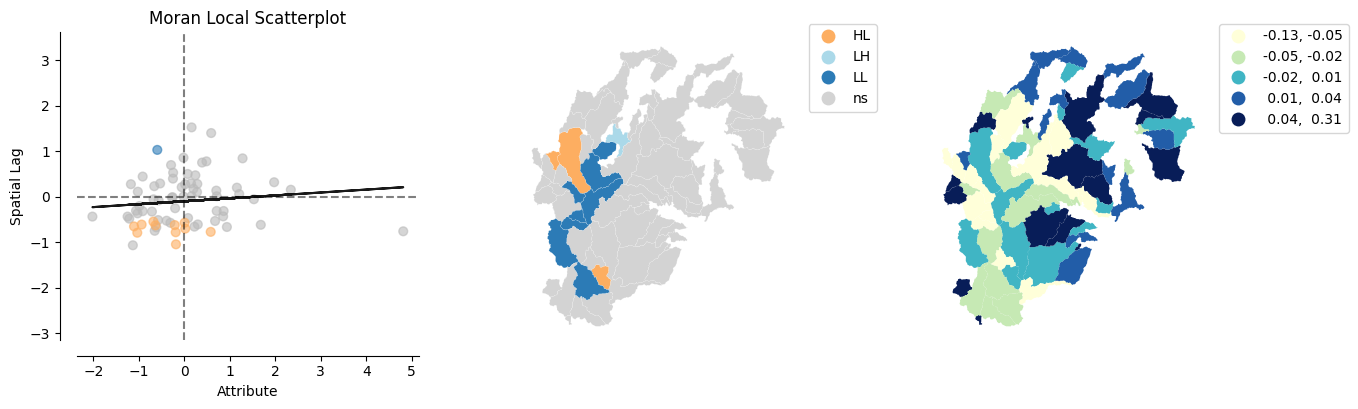

In [13]:
from splot.esda import plot_local_autocorrelation
plot_local_autocorrelation(lisa, cuencas, 'residuo')

### Análisis de Moran y Lisa para Beta media en la cuenca

0.491504412779848
0.001


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Reference Distribution'}, xlabel='Moran I: 0.49', ylabel='Density'>,
        <Axes: title={'center': 'Moran Scatterplot (0.49)'}, xlabel='Attribute', ylabel='Spatial Lag'>],
       dtype=object))

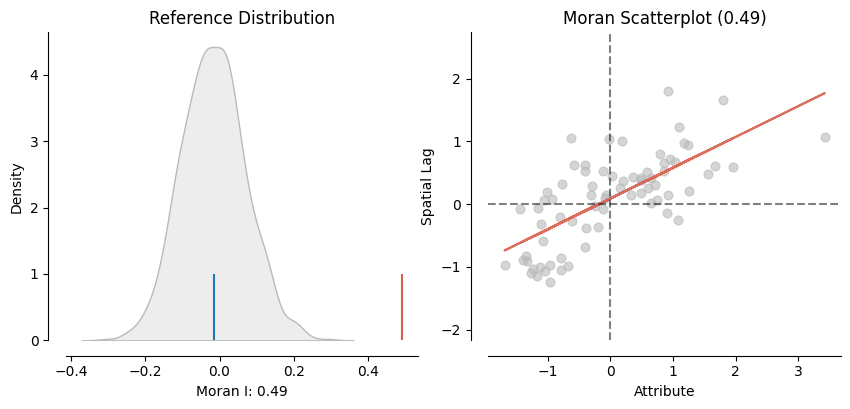

In [14]:
mi_Beta=Moran(cuencas['Beta_media'],w_queen)
print(mi_Beta.I)
print(mi_Beta.p_sim)
plot_moran(mi_Beta)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

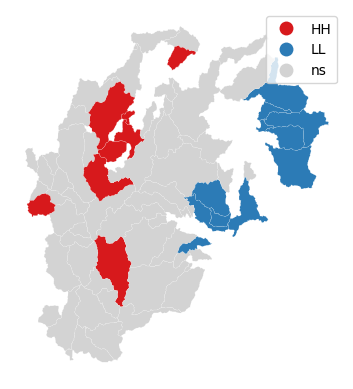

In [15]:
lisa = esda.Moran_Local(cuencas['Beta_media'], w_queen)
from splot.esda import lisa_cluster
lisa_cluster(lisa, cuencas)

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: title={'center': 'Moran Local Scatterplot'}, xlabel='Attribute', ylabel='Spatial Lag'>,
        <Axes: >, <Axes: >], dtype=object))

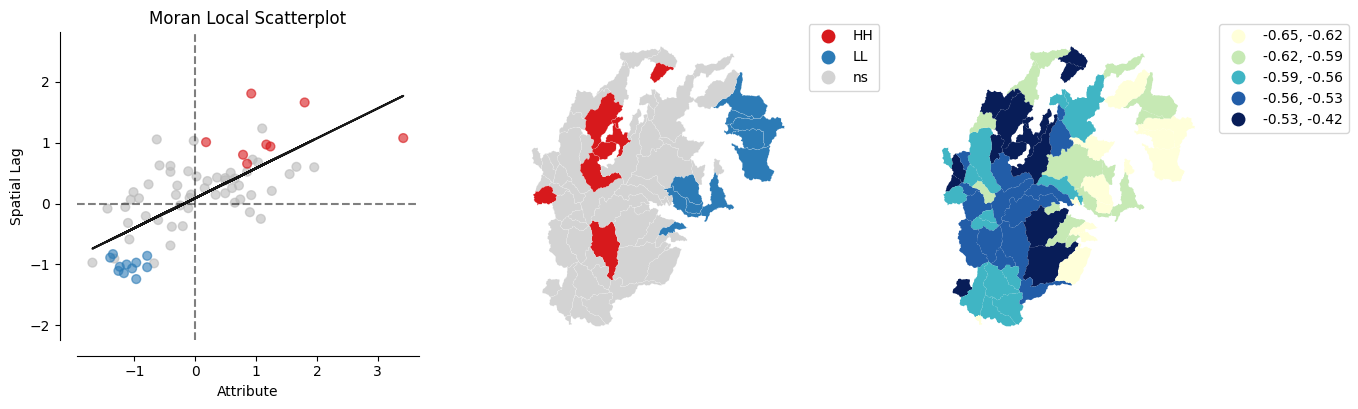

In [16]:
from splot.esda import plot_local_autocorrelation
plot_local_autocorrelation(lisa, cuencas, 'Beta_media')

In [17]:
# ============================================================
# LISA PARA BETA_MEDIA
# ============================================================

variable_lisa = "Beta_media"

lisa_beta = Moran_Local(
    cuencas[variable_lisa].values,
    w_queen,
    permutations=999
)

cuencas["Ii_Beta_media"] = lisa_beta.Is
cuencas["p_Beta_media"] = lisa_beta.p_sim
cuencas["q_Beta_media"] = lisa_beta.q

alpha = 0.05

cuencas["LISA_Beta_media"] = "No significativo"

sig = cuencas["p_Beta_media"] < alpha

cuencas.loc[sig & (cuencas["q_Beta_media"] == 1), "LISA_Beta_media"] = "Alto-Alto"
cuencas.loc[sig & (cuencas["q_Beta_media"] == 2), "LISA_Beta_media"] = "Bajo-Alto"
cuencas.loc[sig & (cuencas["q_Beta_media"] == 3), "LISA_Beta_media"] = "Bajo-Bajo"
cuencas.loc[sig & (cuencas["q_Beta_media"] == 4), "LISA_Beta_media"] = "Alto-Bajo"

print(cuencas["LISA_Beta_media"].value_counts())

LISA_Beta_media
No significativo    52
Bajo-Bajo           11
Alto-Alto            9
Name: count, dtype: int64


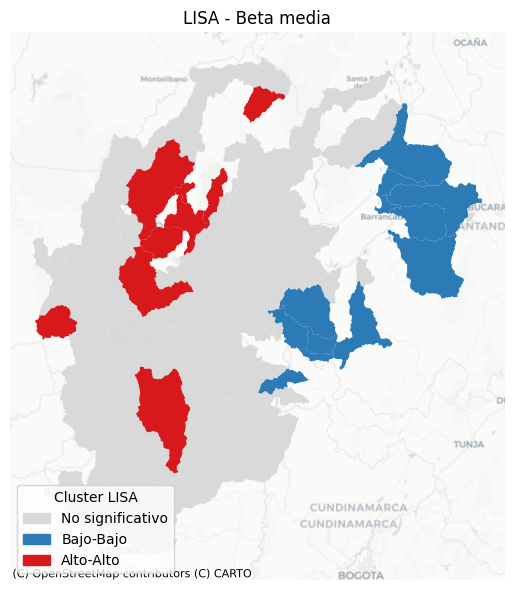

In [18]:
import contextily as ctx
import matplotlib.patches as mpatches

colores_lisa = {
    "Alto-Alto": "#d7191c",
    "Bajo-Bajo": "#2c7bb6",
    "Alto-Bajo": "#fdae61",
    "Bajo-Alto": "#abd9e9",
    "No significativo": "#d9d9d9"
}

fig, ax = plt.subplots(figsize=(6, 6))

clases_presentes = cuencas["LISA_Beta_media"].unique()

for clase in clases_presentes:
    cuencas[cuencas["LISA_Beta_media"] == clase].plot(
        ax=ax,
        color=colores_lisa[clase]
    )

handles = [
    mpatches.Patch(
        color=colores_lisa[clase],
        label=clase
    )
    for clase in clases_presentes
]

ax.legend(
    handles=handles,
    title="Cluster LISA",
    loc="lower left"
)
ctx.add_basemap(ax=ax,crs=cuencas.crs,source=ctx.providers.CartoDB.Positron)
ax.set_title("LISA - Beta media")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Autocorrelaciones e indice de Moran para todas las variables predictivas

Variables analizadas:
['PMA_cuenca', 'altura_mean', 'area[km2]', 'Beta_media', 'Beta_std', 'P24_media', 'P24_std', 'index_extremal']
Número de cuencas usadas: 72
Número de islas: 0
Islas: []
Promedio de vecinos: 3.9722222222222223


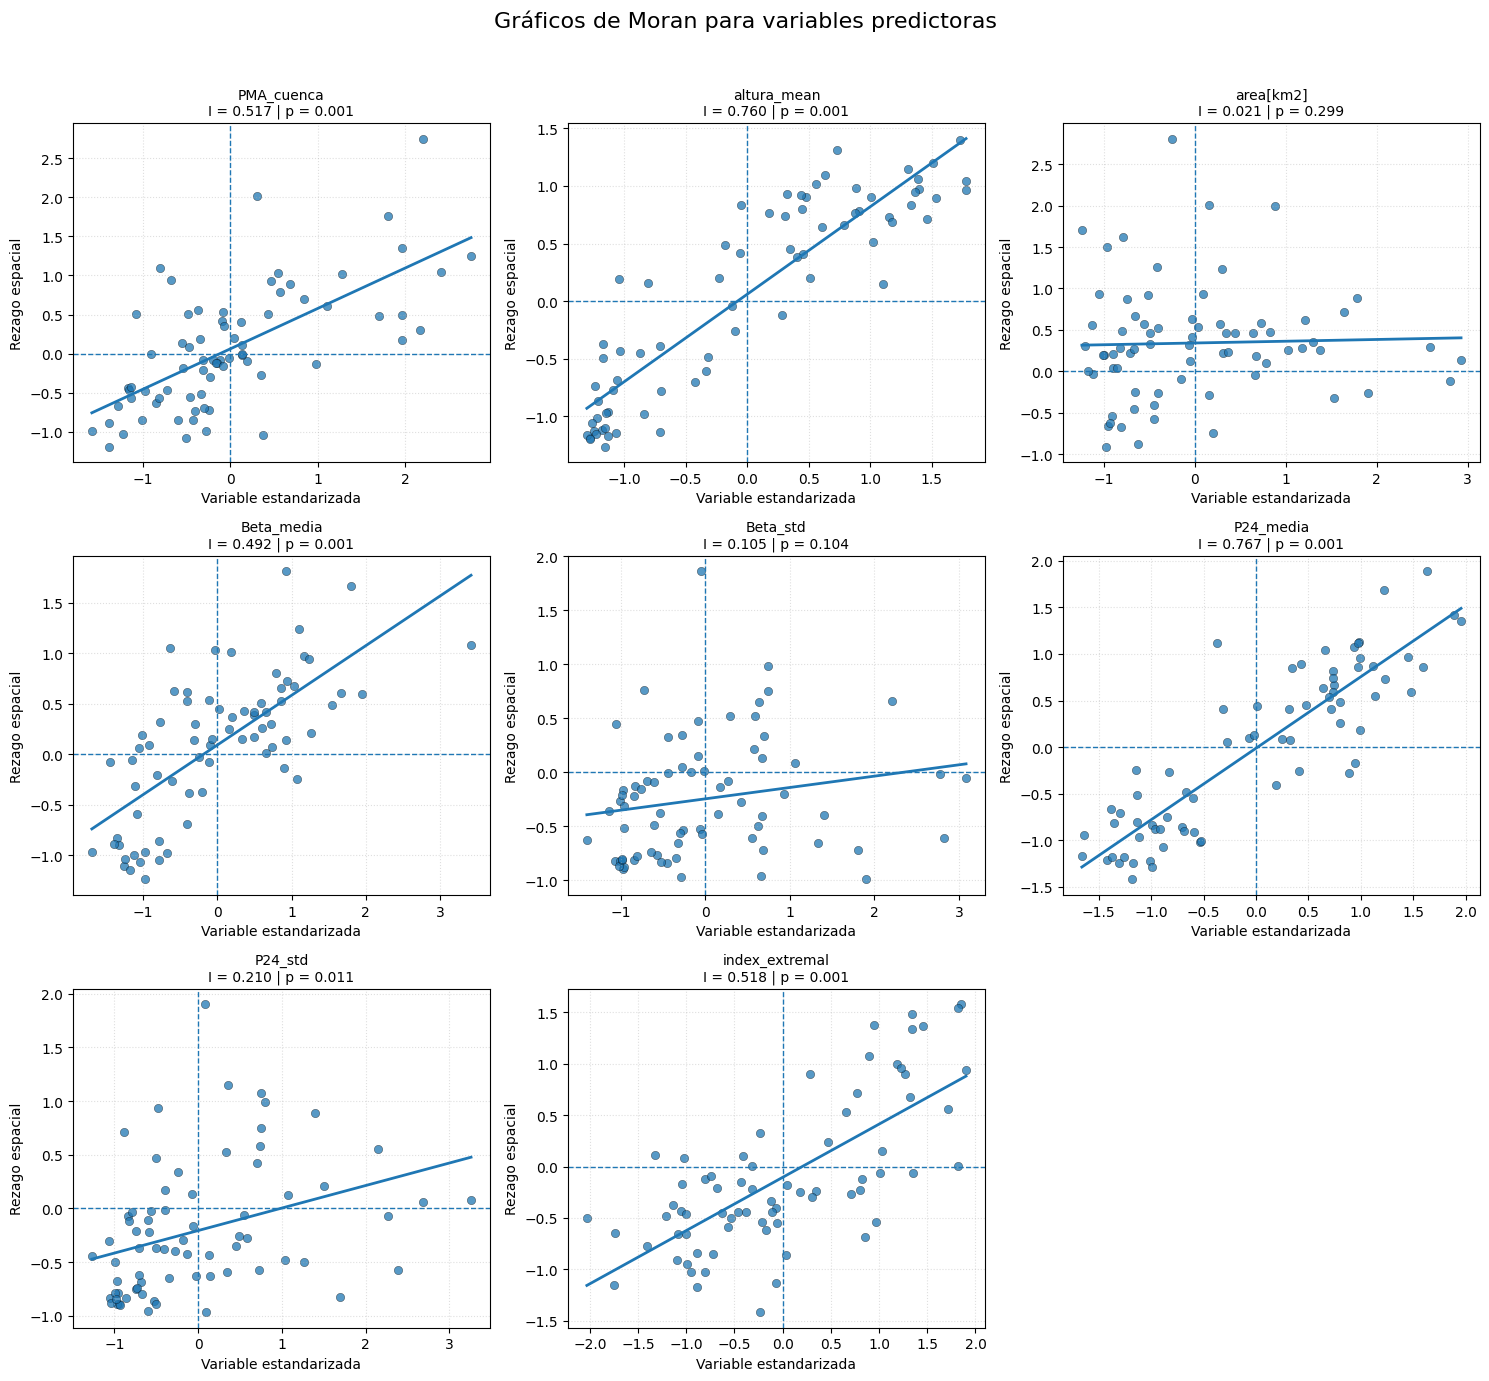

,Variable,Moran_I,p_sim,z_sim,Esperado_I
5,P24_media,0.7675,0.001,8.8969,-0.0141
1,altura_mean,0.7603,0.001,8.8206,-0.0141
7,index_extremal,0.5178,0.001,5.9502,-0.0141
0,PMA_cuenca,0.5167,0.001,6.0362,-0.0141
3,Beta_media,0.4915,0.001,5.7171,-0.0141
6,P24_std,0.2097,0.011,2.5494,-0.0141
4,Beta_std,0.1051,0.104,1.3189,-0.0141
2,area[km2],0.0212,0.299,0.4524,-0.0141


In [19]:
# ============================================================
# GRÁFICOS DE MORAN PARA TODAS LAS VARIABLES PREDICTORAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from libpysal import weights
from libpysal.weights import lag_spatial
from esda.moran import Moran

# ------------------------------------------------------------
# 1. Variables predictoras a analizar
# ------------------------------------------------------------

predictoras = [
    "PMA_cuenca",
    "altura_mean",
    "area[km2]",
    "Beta_media",
    "Beta_std",
    "P24_media",
    "P24_std",
    "index_extremal"
]

# Dejar solo las que existan en la capa
predictoras = [
    var for var in predictoras
    if var in cuencas.columns
]

print("Variables analizadas:")
print(predictoras)

# ------------------------------------------------------------
# 2. Preparar GeoDataFrame
# ------------------------------------------------------------

gdf_moran = cuencas.copy()

# Convertir variables a numéricas
for var in predictoras:
    gdf_moran[var] = pd.to_numeric(
        gdf_moran[var],
        errors="coerce"
    )

# Eliminar filas con datos faltantes en cualquiera de las predictoras
gdf_moran = gdf_moran.dropna(
    subset=predictoras + ["geometry"]
).copy()

# Reiniciar índice para que PySAL no tenga problemas
gdf_moran = gdf_moran.reset_index(drop=True)

print("Número de cuencas usadas:", len(gdf_moran))

# ------------------------------------------------------------
# 3. Matriz Queen
# ------------------------------------------------------------

w_queen = weights.Queen.from_dataframe(
    gdf_moran,
    use_index=False
)

w_queen.transform = "R"

print("Número de islas:", len(w_queen.islands))
print("Islas:", w_queen.islands)
print(
    "Promedio de vecinos:",
    np.mean(list(w_queen.cardinalities.values()))
)

# ------------------------------------------------------------
# 4. Función para graficar Moran plot
# ------------------------------------------------------------

def graficar_moran_variable(ax, gdf, variable, w):
    """
    Grafica el Moran plot para una variable dada.
    """

    y = gdf[variable].values

    # Estandarizar variable
    z = (y - y.mean()) / y.std()

    # Rezago espacial de la variable estandarizada
    wz = lag_spatial(w, z)

    # Moran global
    moran = Moran(
        y,
        w,
        permutations=999
    )

    # Línea de tendencia
    m, b = np.polyfit(z, wz, 1)

    x_line = np.linspace(
        z.min(),
        z.max(),
        100
    )

    y_line = m * x_line + b

    # Gráfico
    ax.scatter(
        z,
        wz,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3
    )

    ax.plot(
        x_line,
        y_line,
        linewidth=2
    )

    # Líneas de cuadrantes
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        f"{variable}\n"
        f"I = {moran.I:.3f} | p = {moran.p_sim:.3f}",
        fontsize=10
    )

    ax.set_xlabel("Variable estandarizada")
    ax.set_ylabel("Rezago espacial")
    ax.grid(
        True,
        linestyle=":",
        alpha=0.4
    )

    return {
        "Variable": variable,
        "Moran_I": moran.I,
        "p_sim": moran.p_sim,
        "z_sim": moran.z_sim,
        "Esperado_I": moran.EI
    }

# ------------------------------------------------------------
# 5. Graficar todas las variables
# ------------------------------------------------------------

n_vars = len(predictoras)

n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4.5 * n_rows)
)

axes = np.array(axes).reshape(-1)

resultados_moran_predictoras = []

for i, variable in enumerate(predictoras):
    resultado = graficar_moran_variable(
        ax=axes[i],
        gdf=gdf_moran,
        variable=variable,
        w=w_queen
    )

    resultados_moran_predictoras.append(resultado)

# Apagar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Gráficos de Moran para variables predictoras",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Tabla resumen
# ------------------------------------------------------------

tabla_moran_predictoras = pd.DataFrame(
    resultados_moran_predictoras
).sort_values(
    "Moran_I",
    ascending=False
)

display(tabla_moran_predictoras.round(4))